# Lab 3: Sentinel-1 Time Series for Crop Growth in Midwest Row-Crop Fields

This notebook is for a lab on seasonal crop growth using Sentinel-1 SAR backscatter in large Midwestern U.S. fields.

The lab is designed to stay fully in Google Earth Engine + Python. We will be:

- building a consistent Sentinel-1 time series,
- selecting individual row-crop fields, forested regions, and towns/cities,
- extracting field-scale backscatter statistics,
- comparing seasonal trajectories,
- proposing a simple crop growth metric based on VV, VH, or VV/VH.

---

## Lab concept

Students will:

1. choose several individual regions in a Midwest US AOI. You do not have to choose a midwest US AOI, but it will be the easiest. Midwest US/Canada has perfectly North/South Aligned farms in 1.5 km grids, which uniformly grow corn/wheat/soy/etc. European farms are much smaller, and randomly oriented. Averaging over an entire field will increase the signal to noise ratio.
2. define field polygons as regions of interest,
3. build a seasonal Sentinel-1 time series,
4. compute field-level summary statistics for:
   - VV
   - VH
   - VV - VH (in dB is a convenient proxy related to VV/VH ratio)
5. interpret how those quantities evolve from:
   - bare ground / early season
   - vegetative growth
   - maturity
   - senescence (interesting fact - senescence progression is monitored via NDVI)
   - harvest

---

## Why the Midwest U.S.?

This is a good teaching region because many fields are:

- large,
- homogeneous,
- easy to outline,
- minimally affected by complex topography,
- dominated by row crops with strong seasonal structure.

That makes field-scale SAR time series much easier to interpret than small, irregular fields. Irregularly oriented fields produce an additional complexity with regards to geometry. You may have noticed when exploring Krakow SAR that the backscatter from farms could vary greatly. This can be due to differences in crop type, but it can also be related to how the rows are oriented with respect to the satellite look direction. Think about the ground texture of farms, there are many small ridges and valleys. If these ridges and valleys are parallel to the satellite look direction, backscatter will be weaker, and if the ridges and valleys are perpendicular to the satellite look direction, backscatter will be stronger.

---

## learning goals

By the end of this lab, students should be able to:

- explain why SAR time series must be filtered consistently,
- compute a field-averaged VV and VH time series,
- compare crop fields with a non-crop control,
- propose and defend simple crop growth metrics,
- explain why VH or VV-VH may respond differently from VV alone.

---

## 1. Imports and Earth Engine initialization

This notebook assumes that students already have:

- a working Python environment,
- the Earth Engine Python API,
- `geemap`,
- libraries `matplotlib` and `pandas`.

In [23]:
import ee
import geemap
import pandas as pd
import json
import matplotlib.pyplot as plt

PROJECT_ID = "gee-lab1-500517"

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine initialized.")

Earth Engine initialized.


## 2. Define an agricultural AOI

This notebook starts with a large AOI in northern Iowa / southern Minnesota.  
You can adjust it later, but it is helpful to begin with a region dominated by large row-crop fields. In one scene, I want you to find a place that has:

- individual crop fields that you can isolate
- A city or town that we're not expecting a strong vegetative growth signal from
- a stand of trees you can isolate

**QUESTION (5pts): Why is the subregion you chose a good choice for exploring crop growth? Trees and crops both have vegetative growth during summer months, but what differences would you expect to see over a year, with regards to VV, VH, and VV-VH? What do you expect to see in the city or town that you have isolated?**

**ANSWER:**
Central Illinois is a strong choice for studying crop growth because it has large, regular agricultural fields that are easy to separate from other land covers. It also includes Bloomington-Normal and nearby wooded areas, which provide useful comparisons between crops, urban surfaces, and trees within the same region.

Over crop fields, VV and especially VH should rise during the growing season as plants become taller and the canopy becomes denser and more structurally complex. After harvest, both signals should drop as biomass is removed. The VV-VH difference should also vary through the year because crop structure changes quickly between planting, peak growth, and harvest.

Forested areas should behave differently. Trees also grow leaves in summer, but their woody structure remains present year-round, so VV and VH should stay relatively strong and change less dramatically than crop fields.

In the city, I would expect VV and VH to remain fairly stable through the year because buildings, roads, and other hard surfaces do not follow a seasonal growth cycle. Urban pixels may stay consistently bright, with only minor variation from moisture, viewing geometry, or noise.

In [24]:
# Agricultural AOI: Central Illinois (Bloomington–Normal)
aoi = ee.Geometry.Rectangle([-89.45, 40.20, -88.75, 40.70])

# Growing season year
YEAR = 2025

# Visualization parameters
vv_vis = {"min": -18, "max": 2}
vh_vis = {"min": -28, "max": -8}
ratio_vis = {"min": 2, "max": 12}

m = geemap.Map(center=[40.45, -89.10], zoom=11)
m.addLayer(aoi, {"color": "red"}, "AOI")
m

Map(center=[40.45, -89.1], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## 3. Helper functions

To keep the notebook readable, the repetitive Earth Engine logic is collected into helper functions.

These functions do most of the work for:

- building a filtered Sentinel-1 collection,
- creating monthly composites,
- computing a convenient VV-VH metric,
- extracting region statistics through time.

---

### Why use `VV - VH` here?

Sentinel-1 GRD backscatter in Earth Engine is in dB.  
So for this lab, instead of using a raw linear ratio `VV/VH`, we use:

\[
VV - VH
\]

because in dB space this is directly related to the log-ratio and is easier to interpret consistently alongside VV and VH.


In [25]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass="ASCENDING",
                      mode="IW",
                      resolution=10):
    """Return a filtered Sentinel-1 GRD collection with VV and VH."""
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(region)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq("instrumentMode", mode))
        .filter(ee.Filter.eq("orbitProperties_pass", orbit_pass))
        .filter(ee.Filter.eq("resolution_meters", resolution))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .select(["VV", "VH"])
    )
    return collection


def monthly_composite(year, month, region=aoi):
    """Return a monthly median Sentinel-1 image with a derived VV-VH band."""
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")

    collection = get_s1_collection(start, end, region=region)
    image = collection.median().clip(region)

    vv_minus_vh = image.select("VV").subtract(image.select("VH")).rename("VV_minus_VH")

    return (
        image.addBands(vv_minus_vh)
        .set({
            "year": year,
            "month": month,
            "system:time_start": start.millis(),
            "scene_count": collection.size()
        })
    )


def build_monthly_stack(year, months=range(3, 11), region=aoi):
    """Create a monthly ImageCollection for a growing season."""
    images = [monthly_composite(year, month, region=region) for month in months]
    return ee.ImageCollection(images)


def region_time_series(image_collection, region, scale=10):
    """Extract field-level mean VV, VH, and VV_minus_VH through time.

    Accepts either an ee.Geometry or an ee.Feature.
    """
    # If region is a Feature, convert it to its geometry
    if isinstance(region, ee.feature.Feature):
        region = region.geometry()

    def per_image(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region,
            scale=scale,
            maxPixels=1e9,
            bestEffort=True
        )
        return ee.Feature(None, {
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
            "year": img.get("year"),
            "month": img.get("month"),
            "scene_count": img.get("scene_count"),
            "VV": stats.get("VV"),
            "VH": stats.get("VH"),
            "VV_minus_VH": stats.get("VV_minus_VH")
        })

    return ee.FeatureCollection(image_collection.map(per_image))

def fc_to_df(fc):
    """Convert an Earth Engine FeatureCollection of stats into a pandas DataFrame."""
    data = fc.getInfo()["features"]
    rows = [f["properties"] for f in data]
    df = pd.DataFrame(rows)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        df = df.sort_values("date").reset_index(drop=True)
    return df


## 4. Build a seasonal Sentinel-1 time series

We build monthly median images from February through November.

**QUESTION (5pts): What are the advantages and disadvantages of using monthly median stacks instead of relying on single scenes? In what circumstances would you not want to do any temporal averaging, and instead rely on single scenes?**

**ANSWER:**
Monthly median stacks are useful because they reduce speckle noise and limit the effect of unusual individual scenes caused by rain, soil moisture, temporary flooding, or sensor noise. They also make the time series smoother, which helps reveal seasonal crop growth patterns. The drawback is that monthly medians can smooth over short-lived events such as harvest, irrigation, flooding, storm damage, or rapid crop changes. I would avoid temporal averaging when the timing of an event matters or when the feature being studied changes quickly, because a single scene may preserve information that a monthly composite would hide.

**QUESTION (5pts): Why do we filter Sentinel-1 by orbit direction, instrument mode, polarization, and resolution before building the time series? What might happen if ascending and descending passes were mixed in the same time series?**

**ANSWER:**
We filter Sentinel-1 by orbit direction, instrument mode, polarization, and resolution so that the time series is internally consistent. Backscatter depends not only on the ground surface, but also on acquisition geometry and sensor settings. If ascending and descending passes were mixed, the radar would view the same surface from opposite directions, which could change the measured VV and VH values even if the land cover stayed the same. This would make geometry-driven differences look like crop or land-cover change.


In [26]:
months = list(range(2, 12))  # February through November
monthly_stack = build_monthly_stack(YEAR, months=months, region=aoi)

print("Monthly images in stack:", monthly_stack.size().getInfo())

# Check how many scenes contribute to each month
for month in months:
    img = monthly_composite(YEAR, month, aoi)
    print(f"Month {month:02d}: {ee.Number(img.get('scene_count')).getInfo()} scenes")


Monthly images in stack: 10
Month 02: 8 scenes
Month 03: 7 scenes
Month 04: 8 scenes
Month 05: 7 scenes
Month 06: 8 scenes
Month 07: 7 scenes
Month 08: 8 scenes
Month 09: 7 scenes
Month 10: 8 scenes
Month 11: 9 scenes


## 5. Quick visual inspection

Before drawing fields, it is useful to inspect one or two monthly composites.

Suggested things to look for:

- field texture,
- strong contrasts between different fields,
- stable non-crop controls such as roads, towns, or tree patches.

**QUESTION (10pts): Compare an early month with a peak month visually. Feel free to change the months plotted, or add in comparisons of early vs mid- season VV_minus_VH, for your investigations. Take particular note of how much VH changes vs how much VV changes. What regions do you think you will choose for your ROI's and why? If you want an extra challenge (but not necessary), try to find a field you think was tall crops, a field you think was short crops, and a field you think was left barren.**

**ANSWER:**
When comparing an early-season month with a peak growing-season month, the biggest visual change is in VH. Agricultural fields become much brighter in VH during peak growth because the crop canopy becomes taller, denser, and more structurally complex, which increases volume scattering. VV also changes, but usually less dramatically because it is more strongly influenced by surface roughness and soil moisture.

For ROIs, I would choose several large, uniform crop fields so that each sample represents one dominant land-cover type. I would also include a forest patch and part of Bloomington-Normal as comparison areas. The forest should show higher but more stable vegetation backscatter, while the city should remain mostly consistent through the season. Within the crop fields, I would select one field with a strong seasonal VH increase as a likely tall-crop field, one with a moderate increase as a possible short-crop field, and one with little seasonal change as a possible barren or fallow field.

In [27]:
img_early = monthly_composite(YEAR, 2, aoi)
img_peak = monthly_composite(YEAR, 7, aoi)

#YOUR CODE HERE: The lines above grab the montlhy composite images for February and July. I want you to plot a split_map image of the VH channel in this cell, and in the cell below plot a split_map image of the VV channel for the same months.
m = geemap.Map(center=[40.45, -89.10], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VH"), vh_vis, "VH February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VH"), vh_vis, "VH July")
)
display(m)
#m.addLayer(aoi, {"color": "red"}, "AOI")

Map(center=[40.45, -89.1], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_o…

In [28]:
#Plot the VV split_map here.

m = geemap.Map(center=[40.45, -89.10], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VV"), vv_vis, "VV February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VV"), vv_vis, "VV July")
)
display(m)

Map(center=[40.45, -89.1], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_o…

# 6. Draw field polygons

Use the map drawing tools to create several polygons:

- at least **two different crop fields**
- at least **two control areas** (1 patch of trees, 1 city or town)

### Suggested strategy
Pick fields that are:

- large,
- internally uniform,
- clearly separated from neighboring fields.

After drawing polygons on the map, export them to Earth Engine objects.

**NOTE: You will need to remember the order of the ROI's you chose. For example, remember that you first chose three farm fields, then a tree stand, then the city/town. In the next section, you will need to assign these drawn features to variables and a dictionary.**



In [29]:
m = geemap.Map(center=[40.45, -89.10], zoom=11)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
m.addLayer(img_peak.select("VH"), vh_vis, "VH July")
#m.addLayer(aoi, {"color": "red"}, "AOI")
m

# After drawing polygons with the map tools, use:
# drawn_fc = m.draw_features

Map(center=[40.45, -89.1], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [30]:
drawn_fc = m.draw_features
print(drawn_fc)

[]


## 7. Make sure your drawn features are where you want them.

To do this, you will need to need to adjust the code below to match the order and number of ROI's you chose to investigate.


In [32]:
# Ręczne przypisanie zapisanych współrzędnych (zamiast rysowania)
field_1 = ee.Feature(ee.Geometry.Polygon([[[-89.294208, 40.447522], [-89.294208, 40.455555], [-89.27945, 40.455555], [-89.27945, 40.447522], [-89.294208, 40.447522]]], None, False))
field_2 = ee.Feature(ee.Geometry.Polygon([[[-89.238501, 40.507482], [-89.238501, 40.514791], [-89.228548, 40.514791], [-89.228548, 40.507482], [-89.238501, 40.507482]]], None, False))
field_3 = ee.Feature(ee.Geometry.Polygon([[[-89.111635, 40.297046], [-89.111635, 40.309221], [-89.088984, 40.309221], [-89.088984, 40.297046], [-89.111635, 40.297046]]], None, False))
trees_1 = ee.Feature(ee.Geometry.Polygon([[[-88.881194, 40.656677], [-88.881194, 40.659884], [-88.875574, 40.659884], [-88.875574, 40.656677], [-88.881194, 40.656677]]], None, False))
control_1 = ee.Feature(ee.Geometry.Polygon([[[-89.017567, 40.478266], [-89.017567, 40.487536], [-89.000408, 40.487536], [-89.000408, 40.478266], [-89.017567, 40.478266]]], None, False))

roi_dict = {
    "Field_1": field_1,
    "Field_2": field_2,
    "Field_3": field_3,
    "Trees_1": trees_1,
    "Control_1": control_1
}

m = geemap.Map(center=[40.45, -89.10], zoom=11)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)
m

##PLEASE PASTE THE OUTPUT OF THIS AS A COMMENT HERE SO THAT I KNOW WHICH ROI's YOU CHOSE
for name, roi in roi_dict.items():
    print(name, roi.geometry().getInfo())
#Field_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-89.294208, 40.447522], [-89.294208, 40.455555], [-89.27945, 40.455555], [-89.27945, 40.447522], [-89.294208, 40.447522]]]}
#Field_2 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-89.238501, 40.507482], [-89.238501, 40.514791], [-89.228548, 40.514791], [-89.228548, 40.507482], [-89.238501, 40.507482]]]}
#Field_3 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-89.111635, 40.297046], [-89.111635, 40.309221], [-89.088984, 40.309221], [-89.088984, 40.297046], [-89.111635, 40.297046]]]}
#Trees_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-88.881194, 40.656677], [-88.881194, 40.659884], [-88.875574, 40.659884], [-88.875574, 40.656677], [-88.881194, 40.656677]]]}
#Control_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-89.017567, 40.478266], [-89.017567, 40.487536], [-89.000408, 40.487536], [-89.000408, 40.478266], [-89.017567, 40.478266]]]}

Field_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-89.294208, 40.447522], [-89.294208, 40.455555], [-89.27945, 40.455555], [-89.27945, 40.447522], [-89.294208, 40.447522]]]}
Field_2 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-89.238501, 40.507482], [-89.238501, 40.514791], [-89.228548, 40.514791], [-89.228548, 40.507482], [-89.238501, 40.507482]]]}
Field_3 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-89.111635, 40.297046], [-89.111635, 40.309221], [-89.088984, 40.309221], [-89.088984, 40.297046], [-89.111635, 40.297046]]]}
Trees_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-88.881194, 40.656677], [-88.881194, 40.659884], [-88.875574, 40.659884], [-88.875574, 40.656677], [-88.881194, 40.656677]]]}
Control_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-89.017567, 40.478266], [-89.017567, 40.487536], [-89.000408, 40.487536], [-89.000408, 40.478266], [-89.017567, 40.478266]]]}


## 8. Extract time series for each field

For each ROI, compute a field-mean time series of:

- VV
- VH
- VV - VH

This is the core analysis step of the lab.

In [33]:
ts_dict = {}

for name, geom in roi_dict.items():
    fc = region_time_series(monthly_stack, geom, scale=10)
    df = fc_to_df(fc)
    ts_dict[name] = df

ts_dict["Field_1"]


,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-21.631563,-12.687473,8.944089,2025-02-01,2,8,2025
1,-25.299610,-12.657807,12.641803,2025-03-01,3,7,2025
2,-26.995573,-14.483659,12.511914,2025-04-01,4,8,2025
3,-26.635750,-13.749102,12.886648,2025-05-01,5,7,2025
4,-17.406231,-10.539481,6.866750,2025-06-01,6,8,2025
5,-18.074582,-12.016558,6.058024,2025-07-01,7,7,2025
6,-18.354630,-11.865928,6.488702,2025-08-01,8,8,2025
7,-19.646695,-13.271754,6.374941,2025-09-01,9,7,2025
8,-23.476745,-14.264048,9.212697,2025-10-01,10,8,2025
9,-21.975432,-12.981712,8.993720,2025-11-01,11,9,2025


**QUESTION (5pts): Which month has the minimum VH? Which month has the maximum VH? Does this match what you expected from the image comparison?**

**ANSWER:**
The minimum VH occurs in April, with a value of about -27.0 dB, while the maximum VH occurs in June, with a value of about -17.4 dB. This matches the image comparison because VH is weakest early in the season when crop biomass is low, then increases as the crop canopy develops and volume scattering becomes stronger. The June maximum is consistent with peak or near-peak vegetation growth in the selected field.

## 9. Plot VV, VH, and VV-VH through time

These plots are where the crop-growth story should begin to emerge.

**QUESTION (20pts):**
- Qualitatively compare your three different types of ROI's (1) farms; (2) trees; and (3) towns. A few sentences to a short paragraph is enough.
- Based on these plots, identify the months that (1) crops started growing; (2) crops stopped growing; and (3) crops were harvested.
- Does VV-VH separate crops from control AOI's better than VV alone?
- Which ROI looks least like an actively growing crop field?
- Which ROI shows the strongest seasonal change in VH? Which ROI is most stable through time? Explain whether each behavior is more consistent with crop growth, forest canopy, or built-up land.

**ANSWER:**

ROI comparison:
The farm ROIs show the clearest seasonal pattern. Their VH values increase strongly during the growing season as crop biomass and canopy structure develop, then drop after harvest. The tree ROI has consistently strong VH backscatter because forests have a persistent woody and leafy canopy, so the seasonal change is smaller than in crop fields. The town/control ROI is the most stable because buildings, roads, and other hard surfaces do not follow a vegetation growth cycle.

Crop timing:
Based on the time-series plots, crop growth appears to begin around May to June, when VH rises sharply and VV-VH changes noticeably. The crops seem to reach peak growth or stop major growth around June through September, when the curves flatten or remain relatively stable. Harvest likely occurs around September to October, shown by the sharp VH decrease and the return toward a bare-soil-like radar response.

VV-VH vs. VV:
In this case, VV alone appears to separate the crop fields from the control ROIs better than VV-VH during much of the season. The VV values for trees and built-up areas stay relatively distinct from the crop fields, while the VV-VH values overlap more during the peak growing months. This means VV-VH is useful for tracking crop growth, but it does not always provide the clearest separation from the control areas.

Least crop-like ROI:
The town/control ROI looks least like an actively growing crop field. It has very little seasonal variation and lacks the strong increase-and-drop pattern associated with crop growth and harvest.

Seasonal change and stability:
The farm fields, especially the field with the largest VH swing, show the strongest seasonal change in VH. This behavior is consistent with active crop growth, where the surface changes from bare or sparse vegetation to a dense canopy and then back after harvest. The town/control ROI is the most stable through time, which fits built-up land. The tree ROI is also fairly stable, but its consistently high VH reflects persistent forest canopy structure rather than urban surfaces.

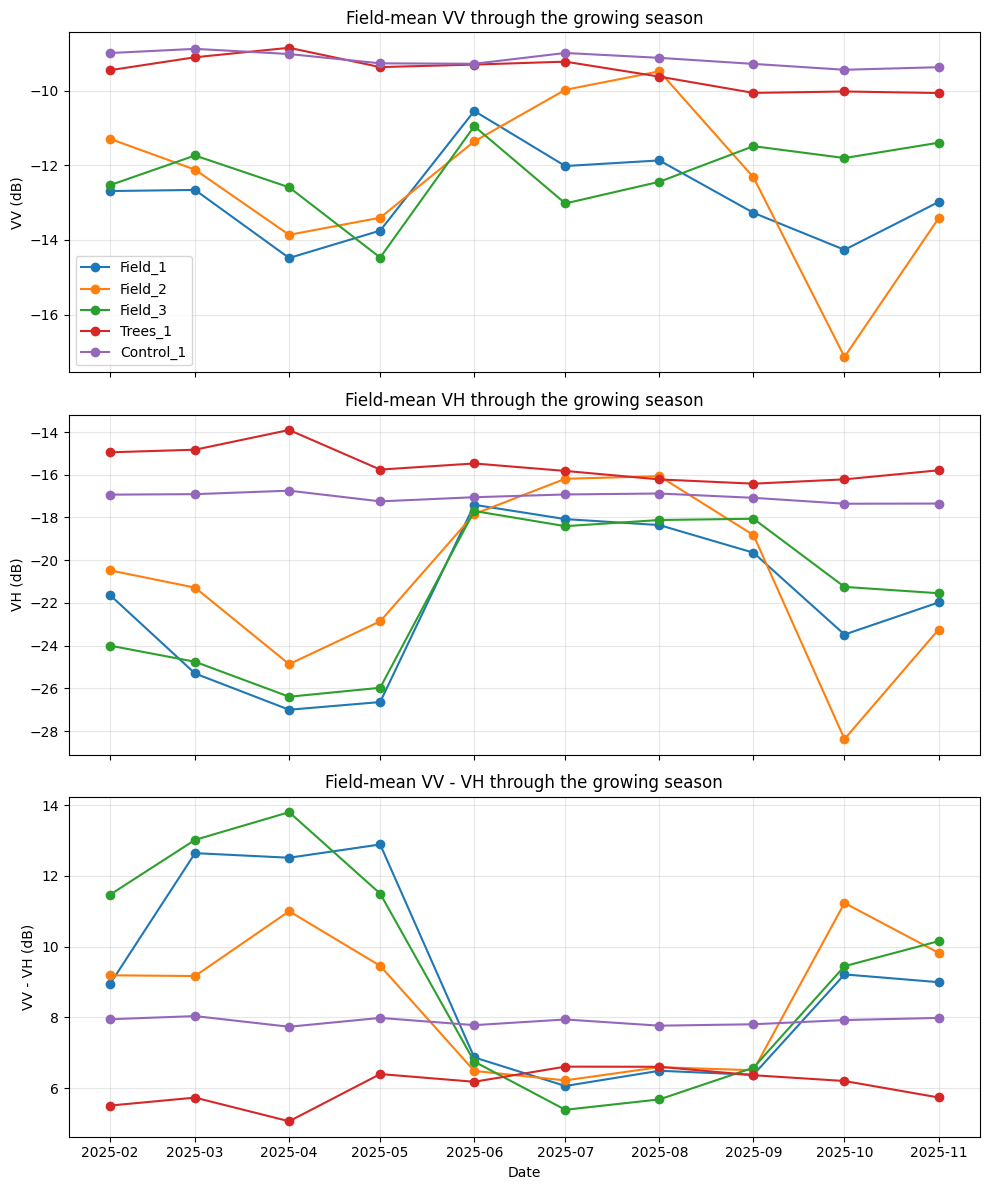

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for name, df in ts_dict.items():
    axes[0].plot(df["date"], df["VV"], marker="o", label=name)
    axes[1].plot(df["date"], df["VH"], marker="o", label=name)
    axes[2].plot(df["date"], df["VV_minus_VH"], marker="o", label=name)

axes[0].set_title("Field-mean VV through the growing season")
axes[0].set_ylabel("VV (dB)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Field-mean VH through the growing season")
axes[1].set_ylabel("VH (dB)")
axes[1].grid(True, alpha=0.3)

axes[2].set_title("Field-mean VV - VH through the growing season")
axes[2].set_ylabel("VV - VH (dB)")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()


## 10. Build a simple crop-growth metric

Next I want you to propose a metric that captures crop development.

Possible first ideas include:

- peak VH minus spring VH,
- July VH minus April VH,
- maximum seasonal VV-VH range,
- cumulative increase from planting to peak growth.

Below is one simple example:

\[
Growth Metric = VH_{peak} - VH_{early}
\]

This is not necessarily the best metric — it is just a starting point.



In [35]:
##YOUR CODE HERE (50pts)
growth_metric = img_peak.select("VH").subtract(img_early.select("VH"))

## 11. Optional: compare fields spatially for one month

It is often useful to look at the mapped field values in the month of strongest contrast.

This can help connect your field-average statistics back to the actual imagery.


In [36]:
img_july = monthly_composite(YEAR, 7, aoi)

m = geemap.Map(center=[40.45, -89.10], zoom=11)
m.addLayer(img_july.select("VV"), vv_vis, "VV July")
m.addLayer(img_july.select("VH"), vh_vis, "VH July")
m.addLayer(img_july.select("VV_minus_VH"), ratio_vis, "VV-VH July")

for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)

m

Map(center=[40.45, -89.1], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## 12. Optional: identify likely tall vs shorter crops

With Sentinel-1 alone, you should not make an overconfident crop-type classification.  
But you can propose that one field is more consistent with a tall, strongly volume-scattering canopy than another.

For example:
- stronger seasonal VH increase,
- larger mid-season drop in VV-VH,
- more pronounced growth curve.


## Final note
This lab is designed to connect a simple SAR observable to a real seasonal process.  
The goal is not perfect crop classification, but rather to help reason from:

- backscatter,
- polarization,
- time,
- and field geometry

toward a physically grounded interpretation of crop growth.
